# YOLOE: Real-Time Seeing Anything

YOLOE (Real-Time Seeing Anything) is a new advancement in zero-shot, promptable YOLO models, designed for open-vocabulary detection and segmentation. Unlike previous YOLO models limited to fixed categories, YOLOE uses text, image, or internal vocabulary prompts, enabling real-time detection of any object class. Built upon YOLOv10 and inspired by YOLO-World, YOLOE achieves state-of-the-art zero-shot performance with minimal impact on speed and accuracy.

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/yoloe/

In [5]:
!nvidia-smi

Fri Nov 21 21:16:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 32%   48C    P5             36W /  250W |    8712MiB /  11264MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download test data

In [4]:
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")

### YOLOE - Text Prompt


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 5 persons, 1 bus, 21.8ms
Speed: 1.7ms preprocess, 21.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


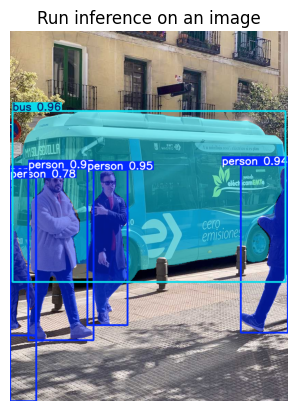

In [3]:
from ultralytics import YOLOE
import matplotlib.pyplot as plt
import cv2

# Initialize a YOLOE model
model = YOLOE("./temp_model/yoloe-11l-seg.pt")  # or select yoloe-11s/m-seg.pt for different sizes

# Set text prompt to detect person and bus. You only need to do this once after you load the model.
names = ["person", "bus"]
model.set_classes(names, model.get_text_pe(names))

# Execute prediction for specified categories on an image
results = model.predict("./temp_assets/bus.jpg")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

### YOLOE - Visual Prompt

Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10815MiB)
YOLOe-11l-seg summary (fused): 227 layers, 35,117,862 parameters, 2,254,374 gradients

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 3 object0s, 2 object1s, 28.0ms
Speed: 5.1ms preprocess, 28.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


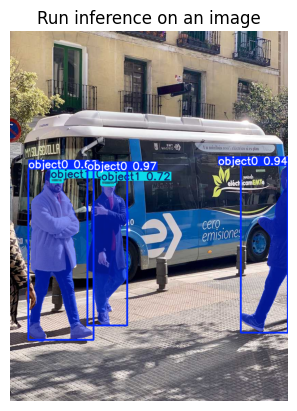

In [5]:
import numpy as np

from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor
import matplotlib.pyplot as plt
import cv2

# Initialize a YOLOE model
model = YOLOE("./temp_model/yoloe-11l-seg.pt")

# Define visual prompts using bounding boxes and their corresponding class IDs.
# Each box highlights an example of the object you want the model to detect.
visual_prompts = dict(
    bboxes=np.array(
        [
            [221.52, 405.8, 344.98, 857.54],  # Box enclosing person
            [120, 425, 160, 445],  # Box enclosing glasses
        ],
    ),
    cls=np.array(
        [
            0,  # ID to be assigned for person
            1,  # ID to be assigned for glassses
        ]
    ),
)

# Run inference on an image, using the provided visual prompts as guidance
results = model.predict(
    "./temp_assets/bus.jpg",
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor,
)

# Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10815MiB)
YOLOe-11l-seg summary (fused): 227 layers, 35,117,862 parameters, 2,254,374 gradients

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 384x640 2 object0s, 46.0ms
Speed: 1.1ms preprocess, 46.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


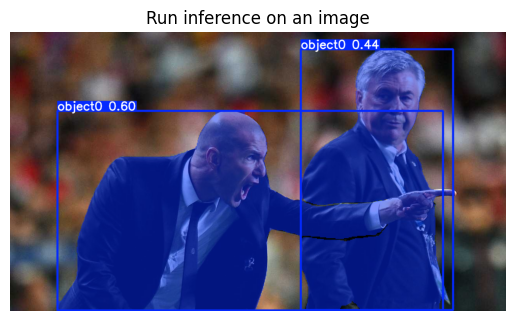

In [6]:
import numpy as np

from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor
import matplotlib.pyplot as plt
import cv2

# Initialize a YOLOE model
model = YOLOE("./temp_model/yoloe-11l-seg.pt")

# Define visual prompts based on a separate reference image
visual_prompts = dict(
    bboxes=np.array([[221.52, 405.8, 344.98, 857.54]]),  # Box enclosing person
    cls=np.array([0]),  # ID to be assigned for person
)

# Run prediction on a different image, using reference image to guide what to look for
results = model.predict(
    "./temp_assets/zidane.jpg",  # Target image for detection
    refer_image="./temp_assets/bus.jpg",  # Reference image used to get visual prompts
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor,
)

# Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10815MiB)
YOLOe-11l-seg summary (fused): 227 layers, 35,117,862 parameters, 2,254,374 gradients

0: 640x640 4 object0s, 2 object1s, 23.1ms
1: 640x640 2 object0s, 23.1ms
Speed: 2.0ms preprocess, 23.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
2


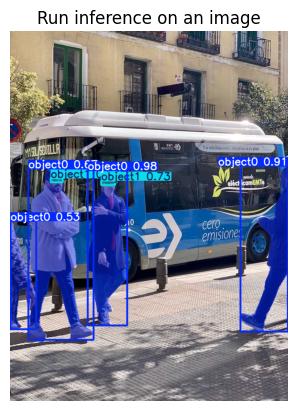

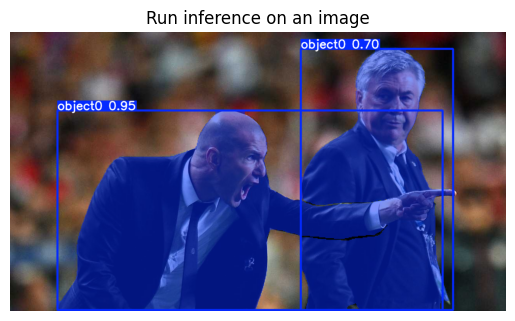

In [ ]:
import numpy as np

from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor
import matplotlib.pyplot as plt
import cv2

# Initialize a YOLOE model
model = YOLOE("./temp_model/yoloe-11l-seg.pt")

# Define visual prompts using bounding boxes and their corresponding class IDs.
# Each box highlights an example of the object you want the model to detect.
visual_prompts = dict(
    bboxes=[
        np.array(
            [
                [221.52, 405.8, 344.98, 857.54],  # Box enclosing person
                [120, 425, 160, 445],  # Box enclosing glasses
            ],
        ),
        np.array([[150, 200, 1150, 700]]),
    ],
    cls=[
        np.array(
            [
                0,  # ID to be assigned for person
                1,  # ID to be assigned for glasses
            ]
        ),
        np.array([0]),
    ],
)

# Run inference on multiple image, using the provided visual prompts as guidance
results = model.predict(
    ["./temp_assets/bus.jpg", "./temp_assets/zidane.jpg"],
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor,
)

# Show results
# results[0].show()
print(len(results))
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

bgr_image = results[1].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

### YOLOE - Prompt Free


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 1 bus, 1 can, 1 glasses, 1 hiking boot, 5 persons, 2 leather shoes, 1 stop sign, 1 tie, 21.3ms
Speed: 1.3ms preprocess, 21.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 480)


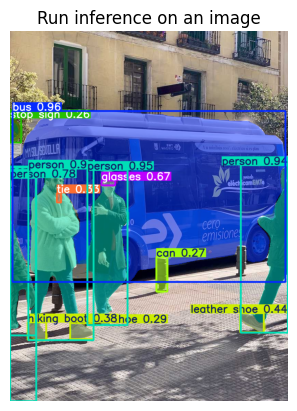

In [ ]:
from ultralytics import YOLOE
import matplotlib.pyplot as plt
import cv2

# Initialize a YOLOE model
model = YOLOE("./temp_model/yoloe-11l-seg-pf.pt")

# Run prediction. No prompts required.
results = model.predict("temp_assets/bus.jpg")

# Show results
# results[0].show()

bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

### YOLOE-Export Test

Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CPU (Intel Core i9-9900K 3.60GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOe-11l-seg summary (fused): 227 layers, 35,117,862 parameters, 0 gradients, 134.1 GFLOPs

PyTorch: starting from 'temp_model/yoloe-11l-seg.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 38, 8400), (1, 32, 160, 160)) (67.7 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.10.12 environment at: /home/hyunjae/anaconda3/envs/cv_playgrounds
Resolved 10 packages in 575ms
Prepared 3 packages in 700ms
Installed 3 packages in 27ms
 + colorama==0.4.6
 + ml-dtypes==0.5.4
 + onnxslim==0.1.75

requirements: AutoUpdate success ✅ 1.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming wi

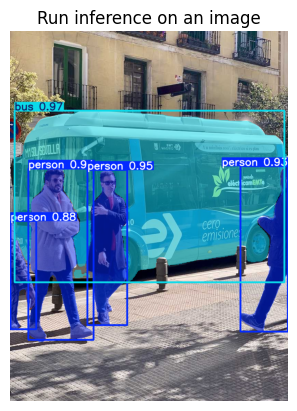

In [12]:
from ultralytics import YOLOE
import matplotlib.pyplot as plt
import cv2

# Select yoloe-11s/m-seg.pt for different sizes
model = YOLOE("./temp_model/yoloe-11l-seg.pt")

# Configure the set_classes() before exporting the model
names = ["person", "bus"]
model.set_classes(names, model.get_text_pe(names))

export_model = model.export(format="onnx")
model = YOLOE(export_model)

# Run detection on the given image
results = model.predict("temp_assets/bus.jpg")

# Show results
# results[0].show()

bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()